# Questão 2


## Letra A

O objetivo é mostrar que $R_{X, s} \circ L_{X} = id_{P_d}$, ou seja, para todo $p \in P_{d}$, $R_{X, d}(L_{X}(p)) = p$.

Por definição, $R_{X, s}(L_{X}(p))$ é igual ao polinômio $q \in P_{d}$ que minimiza $\|L_{X}(q) - L_{X}(p)\|_2^2$. Sabemos que $\|L_{X}(q) - L_{X}(p)\|_2^2 \geq 0$ para todo $p$ e $q$. Então, o valor de $\|L_{X}(q) - L_{X}(p)\|_2^2$ é minimizado quando ocorre a igualdade:

$$\|L_{X}(q) - L_{X}(p)\|_2^2 = 0 \iff \|L_{X}(q) - L_{X}(p)\|_2 = 0$$

Pela definição de norma, temos $\|L_{X}(q) - L_{X}(p)\|_2 = 0 \iff L_{X}(q) - L_{X}(p) = 0$. Conforme demonstrado na questão 1 item d, o funcional de avaliação $L_{X}$ é injetivo (posto completo com $m \geq d + 1$), dessa forma $L_{X}(q) - L_{X}(p) = 0 \iff L_{X}(q) = L_{X}(p) \iff q = p$. Portanto, $R_{X, d}(L_{X}(p)) = p$ para todo $p \in P_{d}$. 

Provamos então que $R_{X, d}$ é uma inversa a esquerda de $L_{X}$.



## Letra B

O objetivo é se convencer de que $R_{X, d}$ é uma transformação linear. 

Qualquer $p \in P_{d}$ pode ser escrito na base canônica dos polinômios como $\sum_{i = 0}^{d} \alpha_{i}x^{i}$, então o funcional de avaliação $L_{X}(p)$ equivale a:

$$
L_{X}(p) =
\begin{bmatrix}
p(x_1)\\
p(x_2)\\
\vdots\\
p(x_m)
\end{bmatrix} =
\begin{bmatrix}
\sum_{i = 0}^{d} \alpha_{i}x_1^{i}\\
\sum_{i = 0}^{d} \alpha_{i}x_2^{i}\\
\vdots\\
\sum_{i = 0}^{d} \alpha_{i}x_m^{i}
\end{bmatrix}
$$

Note que podemos compreender cada somatório como um produto interno entre uma linha $(1, x_i, x_i^2, x_i^3, \dots, x_i^d)$ pelo vetor coluna $(\alpha_0, \alpha_1, \alpha_2, \dots, \alpha_d)^{T}$, então é intuitivo visualizar $L_{X}(p)$ como o resultado de uma multiplicação de uma matriz com $m$ linhas em que a i-ésima linha equivale ao vetor $(1, x_i, x_i^2, x_i^3, \dots, x_i^d)$, pelo vetor coluna $(\alpha_0, \alpha_1, \alpha_2, \dots, \alpha_d)^{T}$. Logo:

$$
L_{X}(p) =
\begin{bmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^d \\
1 & x_2 & x_2^2 & \cdots & x_2^d \\
1 & x_3 & x_3^2 & \cdots & x_3^d \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_m & x_m^2 & \cdots & x_m^d
\end{bmatrix}
.
\begin{bmatrix}
\alpha_0\\
\alpha_1\\
\alpha_2\\
\vdots\\
\alpha_d
\end{bmatrix}
$$

A matriz descrita acima é a matriz de Vandermonde ($V$) e o vetor, que chamaremos de $a$, equivale ao vetor de coeficientes do polinômio $p$ escrito na base canônica, portanto:

$$L_{X}(p) = Va$$

Dessa forma, minimizar $\|L_{X}(p) - b\|_2^2$ sobre $p \in P_{d}$ para determinar $R_{X, d}$ equivale a minimizar $\|Va - b\|_2^2$ sobre $a \in \mathbb{R}^{d+1}$. A solução desse problema equivalente é a pseudoinversa de V:

$$a = V^{+}b = (V^{*}V)^{-1}V^{*}b$$

Observação:
- $V^{*}V$ é invertível pelo seguinte teorema: $A^{*}A$ possui inversa $\iff$ $A$ é injetiva. Como no item d da questão 1 provamos que, para $m \geq d + 1$ $V$ é injetiva, $V^{*}V$ é invertível;

Dessa forma, $R_{X, d}(b)$ (encontrar a solução dos mínimos quadrados) nessa base fixada corresponde a aplicar a matriz $V^{+}$ ao vetor $b$. Como $V^{+}$ é uma matriz e toda transformação dada por uma matriz é linear, a aplicação $b \mapsto V^{+}b$ é linear, e, portanto, $R_{X, d}$ é uma **transformação linear**.

## Letra C

## Letra D

Funções úteis:

In [86]:
using LinearAlgebra
using Plots

function vander(pts, d)
    # Vandermonde: cada linha é [1, x, x^2, ..., x^d]
    V = zeros(length(pts), d+1)

    for (id, x) in enumerate(pts)
        for k in 0:d
            V[id, k+1] = x^k
        end
    end

    return V
end

function rx_matrix(V)
    return pinv(V)
end

function line_plot(X, y_1, key_1, y_2, key_2, variable, title)

    p1 = plot(X, y_1, 
        xlabel="$variable", ylabel="$key_1", 
        title="Variação em $key_1", 
        color= :blue,
        yscale= :log, xscale=:identity,

        titlefontsize=14,
        guidefontsize=12,
        tickfontsize=10,
        legend=false
    )

    p2 = plot(X, y_2, 
        xlabel="$variable", ylabel="$key_2", 
        title="Variação em $key_2", 
        color= :red,
        yscale= :log, xscale =:identity,

        titlefontsize=14,
        guidefontsize=12,
        tickfontsize=10,
        legend=false
    )

    plot(p1, p2, layout=(2, 1), 
        plot_title="\n$title", 
        size=(900, 700), 
        plot_titlevspan =0.12,
        margin=5Plots.mm,
        top_margin=5Plots.mm
    )

end


line_plot (generic function with 5 methods)

┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots C:\Users\lisso\.julia\packages\Plots\GIume\src\args.jl:1590
┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots C:\Users\lisso\.julia\packages\Plots\GIume\src\args.jl:1590


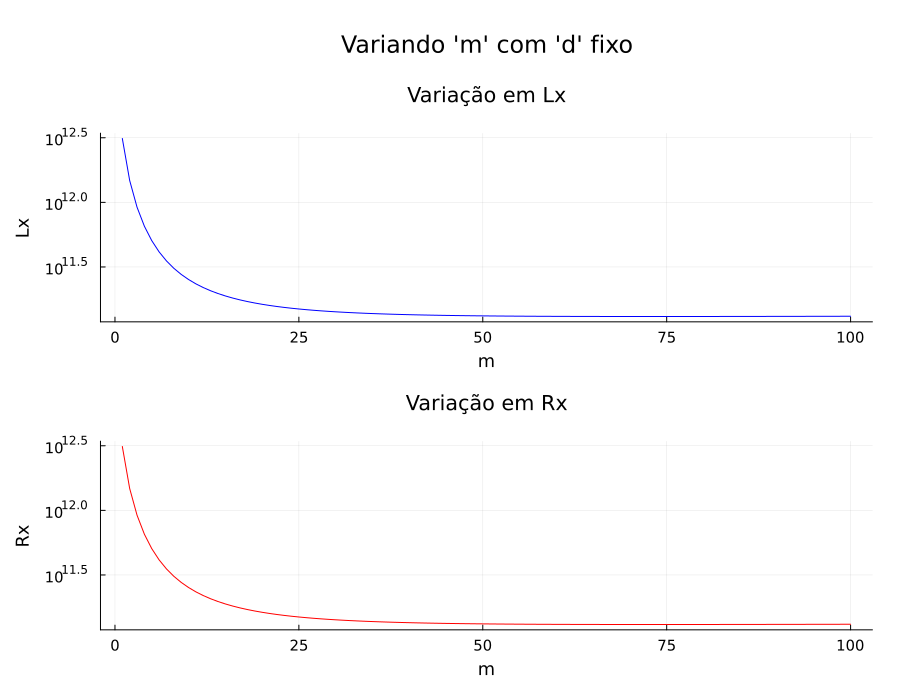

In [91]:

m_values = 1:100
d_values = 1:30

function partial_variation(m_values, d_values)

    m_behavior = Dict("Lx" => zeros(length(m_values)), "Rx" => zeros(length(m_values)))
    d_behavior = Dict("Lx" => zeros(length(d_values)), "Rx" => zeros(length(d_values)))

    # Variando m com d fixo

    # Fixaremos m em 50 para variar d
    X = collect(range(0, 1, length=50))

    for d in d_values
        Lx = vander(X, d)
        Rx = rx_matrix(Lx)

        d_behavior["Lx"][d] = cond(Lx)
        d_behavior["Rx"][d] = cond(Rx)
    end

    # Variando m com d fixo
    for m in m_values

        # Fixaremos d na média
        d = 15
        X = collect(range(0, 1, m+d))

        Lx = vander(X, d)
        Rx = rx_matrix(Lx)

        m_behavior["Lx"][m] = cond(Lx)
        m_behavior["Rx"][m] = cond(Rx)

    end

    
    line_plot(m_values, m_behavior["Lx"], "Lx", m_behavior["Rx"], "Rx", "m", "Variando 'm' com 'd' fixo")

    # return d_behavior, m_behavior
    
end

partial_variation(m_values, d_values)


In [37]:

max_iteration = 100
d = 0

function complete_variation(d, max_iteration)
    
    m_d_behavior = Dict(
            "Lx" => zeros(max_iteration), 
            "Rx" => zeros(max_iteration), 
            "m" => zeros(max_iteration),
            "d" => zeros(max_iteration))

    for iter in 1:max_iteration
        
        # m = d + 5 para sempre garantir que m >= d + 1
        X = rand(d + 5)

        Lx = vander(X, d + iter)
        Rx = rx_matrix(Lx)

        m_d_behavior["m"][iter] = d + 5
        m_d_behavior["d"][iter] = d
        m_d_behavior["Lx"][iter] = cond(Lx)
        m_d_behavior["Rx"][iter] = cond(Rx)

        # println("m:", d+5)
        # println("d:", d)
        # println("cond(Lx):", m_d_behavior["Lx"][iter])
        # println("cond(Rx):", m_d_behavior["Rx"][iter])

        d += 1

    end

    return m_d_behavior
    
end

complete_variation(0, 100)

Dict{String, Vector{Float64}} with 4 entries:
  "Lx" => [4.21707, 389.764, 97321.9, 5.24309e7, 2.15154e8, 2.38106e8, 5.96537e…
  "m"  => [5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0  …  95.0, 96.0…
  "Rx" => [4.21707, 389.764, 97321.9, 5.24309e7, 2.15154e8, 2.38106e8, 5.96538e…
  "d"  => [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  90.0, 91.0, 92.…

## Letra E

Funções úteis:

In [ ]:
# Calcula denomidadores
function lagrange_denominators(X)
    m = length(X)
    denominators = zeros(m)
    for j in 1:m
        den = 1.0
        for k in 1:m
            if k != j
                den *= (X[j] - X[k])
            end
        end
        denominators[j] = den
    end
    return denominators
end

# Calcula numerador e polinômio final, um polinômio por vez
function lagrange_eval(X, denominators, j, y)
    m = length(X)
    num = 1.0
    for k in 1:m
        if k != j
            num *= (y - X[k])
        end
    end
    return num / denominators[j]
end

# Calcula a matriz Lambda (L_Y na base de Lagarange)
function lagrange_matrix(X, Y)
    m = length(X)
    n = length(Y)
    dens = lagrange_denominators(X)
    Lambda = zeros(n, m)
    for (i, y) in enumerate(Y)
        for j in 1:m
            Lambda[i, j] = lagrange_eval(X, dens, j, y)
        end
    end
    return Lambda
end


# Questão 3

## Letra D

### Comentários:

Lembrete:
- $(R_{X,d})_{(d+1) \times m}$
- $(L_X)_{m \times (d+1)}$
- $(L_Y)_{n \times (d+1)}$
- $(L_y \circ R_{X,d})_{n \times m}$

-> Observação sobre o código abaixo na base de Lagrange:

* Caso 1: $m = d+1$

A composta $L_{Y} \circ R_{X, d}$ é uma transformação linear de $\mathbb{R^m} \rightarrow \mathbb{R^n}$, quando representamos essa composta por uma matriz temos uma matriz $n \times m$. Quando $m = d+1$ temos o seguinte:

1. $R_{X, d}$ na base de Lagrange é a identidade $(d + 1) \times (d+1)$ pois pelo item a da questão 1 $R_{X, d} \circ L_X = I$ e $L_x$ na base de Lagrande é a identidade (deve ser demonstrado, vimos um pouco no item g da 1) e a inversa da identidade é a identidade.
2. $L_Y$ na base de Lagrange é uma matriz que nós chamaremos de $\Lambda$ de tamanho $n \times m = n \times (d + 1)$.
3. A composta $L_Y \circ R_{X, d} = L_Y(R_{X, d}) = \Lambda . I = \Lambda$

* Caso 2: $m > d+1$

Na base canônica já conhecemos a matriz, vejamos na base de lagrange. A matriz da composta é dada pela multiplicação de $\Lambda$ (matriz de $L_Y$ na base de Lagrange) multiplicada pela matriz da transformação $R_{X,d}$ na base de Lagrange:

$$M_{lagrande} = \Lambda . R_{X, d}^{Lag}$$

O que significa representar $R_{X,d}$ na base de Lagrange? $R_{X,d}$ recebe um vetor $b \in \mathbb{R^m}$ e devolve um polinômio $p \in P_d$. Para representar isso como uma matriz precisamos expressar $p$ em coordenadas, que dependem da base escolhida. 

Na base de Lagrange $p = c_1p_1 + c_2p_2 + \dots + c_{d+1}p_{d+1}$, então as coordenadas são $c = (c_1, c_2, c_3, \dots, c_{d+1})$. Precisamos encontrar $c$ tal que o polinômio $\sum_{j=1}^{d+1}c_jp_j$ é o que melhor se ajusta a $b$, para isso queremos minimizar a distância entre os valores do polinômio nos pontos de $X$ e os valores observados b:

$$\min_{c}\|p(X) - b\|_2^2 
= 
\min_{c} 
\left\|\begin{bmatrix}
p(x_1)\\
p(x_2)\\
\vdots\\
p(x_m)
\end{bmatrix}
-
\begin{bmatrix}
b_1\\
b_2\\
\vdots\\
b_m
\end{bmatrix}
\right\|_2^2 $$

Dado que estamos buscando minimizar em relação as coordenadas descritas por $c$ precisamos escrever $p(x_i)$ em função das coordenadas $c$ e avaliar $p$ (ou seja, encontrar $c$ que descreve $p$) nos pontos $X$ é exatamente:

$$p(x_i) = \sum_{j=1}^{d+1}c_jp_j(x_i)$$

Empilhando isso  para todos os $x_i$ temos:

$$\begin{bmatrix}
p(x_1)\\
p(x_2)\\
\vdots\\
p(x_m)
\end{bmatrix}
=
\begin{bmatrix}
p_1(x_1) & p_2(x_1) & p_3(x_1) & \cdots & p_{d+1}(x_1)\\
p_1(x_2) & p_2(x_2) & p_3(x_2) & \cdots & p_{d+1}(x_2)\\
p_1(x_3) & p_2(x_3) & p_3(x_3) & \cdots & p_{d+1}(x_3)\\
\vdots & \vdots & \vdots & \ddots & \vdots \\
p_1(x_m) & p_2(x_m) & p_3(x_m) & \cdots & p_{d+1}(x_m)\\
\end{bmatrix}
.
\begin{bmatrix}
c_1\\
c_2\\
\vdots\\
c_{d+1}
\end{bmatrix}
=
L_{X}^{Lag} . c
$$

* Note que essa matriz $L_{X}^{Lag}$ é a identidade nas primiras $d+1$ linhas (pela definição de $p_i$, até $x_d+1$ temos a identidade), a partir da linha $d+1$ temos valores calculáveis, mas não determinados analiticamente.

Nosso problema agora é $min_{c}\|L_{X}^{Lag} . c - b\|_2^2$, caímos novamente no problema de mínimos quadrados convencional, cuja solução ($R_{X,d}$) é $c = (L_X^{Lag})^{+}b$. Portanto, representar $R_{X,d}$ na base de Lagrange é o mesmo que resolver esse problema de mínimos quadrados, logo, $R_{X,d}^{Lag} = (L_X^{Lag})^{+}$, dado que para todo $b$ que passarmos como "input" para $R_{X,d}^{Lag}$ a solução é $(L_X^{Lag})^{+}b$.



In [ ]:
using Printf


# Realiza as compostas para cada trio m, n, d
function compute_compostas(m, n, d)
    try
        X = collect(range(-1, 1, length=m))
        Y = collect(range(-1, 1, length=n))
        X_lag = X[1:d+1]  # primeiros d+1 pontos para base de Lagrange, podemos ter mais

        # Base canônica: não se preocupa com m > d+1 pois o polinômio já existe, só é ajustado
        Vx = vander(X, d)   # L_X que iremos "inverter" para achar R_X,d
        Vy = vander(Y, d)   # L_Y
        M_canonica = Vy * rx_matrix(Vx)  # Composta L_y(R_{x,d})

        # Base de Lagrange: polinômios são construídos a partir dos pontos, se usar m o grau > d
        Lx_lag = lagrange_matrix(X_lag, X)   # L_X que iremos "inverter" para achar R_X,d
        Rx_lag = rx_matrix(Lx_lag)                # R_{x,d}
        Lambda = lagrange_matrix(X_lag, Y)   # L_Y (avaliação dos polinômios construidos por X nos pontos de Y)
        M_lagrange = Lambda * Rx_lag         # Composta L_y(R_{x,d})

        sv_can = svdvals(M_canonica)
        sv_lag = svdvals(M_lagrange)

        # Necessário, explicar por que
        if isempty(sv_can) || isempty(sv_lag)
            return NaN, false
        end

        kappa = sv_can[1] / sv_can[end]

        if isnan(kappa) || isinf(kappa)
            return NaN, false
        end

        matrizes_iguais = isapprox(M_canonica, M_lagrange)
        svs_iguais      = isapprox(sv_can, sv_lag)

        return kappa, matrizes_iguais, svs_iguais

    catch e
        return NaN, false, false
    end
end


# Função auxiliar para extrair resultados filtrando NaN
function extrair_validos(xs, resultados)
    xs_val       = Float64[]
    ks_val       = Float64[]
    matrizes_val = Bool[]
    svs_val      = Bool[]
    for (x, (k, mat_ok, sv_ok)) in zip(xs, resultados)
        if !isnan(k)
            push!(xs_val, x)
            push!(ks_val, k)
            push!(matrizes_val, mat_ok)
            push!(svs_val, sv_ok)
        end
    end
    return xs_val, ks_val, matrizes_val, svs_val
end


# ============================================================
# Tabela: comparação de SVs e matrizes entre bases
# ============================================================
println("=" ^ 60)
println("Tabela: comparação entre bases")
println("=" ^ 60)
println(@sprintf("%-20s %-20s %-20s", "(m, n, d)", "SVs iguais?", "Matrizes iguais?"))
println("-" ^ 60)

configs = [
    (6,  20,  5),
    (10, 20,  5),
    (20, 20,  5),
    (50, 20,  5),
    (6,  50,  5),
    (6, 100,  5),
    (6,  20,  2),
    (6,  20,  4),
    (21, 20, 20),
    (31, 20, 30),
]

for (m, n, d) in configs
    kappa, mat_ok, sv_ok = compute_compostas(m, n, d)
    println(@sprintf("%-20s %-20s %-20s",
        "($m, $n, $d)",
        isnan(kappa) ? "indefinido" : string(sv_ok),
        isnan(kappa) ? "indefinido" : string(mat_ok)))
end

# PLOTS ERRADOS, DESCOBRIR O QUE FAZER

# ============================================================
# Plot 1: Variando n — três configurações fixas de (m, d)
# ============================================================
ns = [10, 20, 50, 100, 200, 300]
configs_n = [(50, 10), (100, 20), (200, 50)]
cores_n   = [:blue, :green, :red]

p1 = plot(title="Efeito de n no condicionamento",
    xlabel="n", ylabel="κ", yscale=:log10, legend=:topright)

for ((m, d), cor) in zip(configs_n, cores_n)
    kappas = [compute_compostas(m, n, d)[1] for n in ns]
    validos = [(n, k) for (n, k) in zip(ns, kappas) if !isnan(k)]
    if !isempty(validos)
        xs = [v[1] for v in validos]
        ys = [v[2] for v in validos]
        plot!(p1, xs, ys, marker=:circle, color=cor, label="m=$m, d=$d")
    end
end


# ============================================================
# Plot 2a: Efeito de m vs d — valor absoluto no eixo x (dois eixos)
# ============================================================
ms_list = [10, 20, 50, 100, 200, 300]
ds_list = [2,   5, 10,  20,  30,  40]
n_fixo  = 50
d_fixo  = 5
m_fixo  = 100

kappas_m = [compute_compostas(m, n_fixo, d_fixo)[1] for m in ms_list]
kappas_d = [compute_compostas(m_fixo, n_fixo, d)[1] for d in ds_list]

# Filtra NaN
validos_m = [(m, k) for (m, k) in zip(ms_list, kappas_m) if !isnan(k)]
validos_d = [(d, k) for (d, k) in zip(ds_list, kappas_d) if !isnan(k)]

xs_m = [v[1] for v in validos_m]
ys_m = [v[2] for v in validos_m]
xs_d = [v[1] for v in validos_d]
ys_d = [v[2] for v in validos_d]

p2a = plot(xs_m, ys_m,
    marker=:circle, color=:green, label="variar m (d=$d_fixo fixo)",
    xlabel="valor do parâmetro", ylabel="κ", yscale=:log10,
    title="Efeito de m vs d (eixo absoluto)")

plot!(twinx(), xs_d, ys_d,
    marker=:square, color=:red, label="variar d (m=$m_fixo fixo)",
    xlabel="", ylabel="κ (d)", yscale=:log10, legend=:bottomright)


# ============================================================
# Plot 2b: Efeito de m vs d — índice do passo no eixo x
# ============================================================
passos = 1:length(ms_list)

p2b = plot(title="Efeito de m vs d (índice do passo)",
    xlabel="passo", ylabel="κ", yscale=:log10, legend=:topright)

# Curva m
idx_m = [i for (i, (_, k)) in enumerate(zip(ms_list, kappas_m)) if !isnan(k)]
ys_m2 = [k for k in kappas_m if !isnan(k)]
labels_m = ["m=$(ms_list[i])" for i in idx_m]
plot!(p2b, idx_m, ys_m2,
    marker=:circle, color=:green, label="variar m (d=$d_fixo fixo)")

# Curva d
idx_d = [i for (i, (_, k)) in enumerate(zip(ds_list, kappas_d)) if !isnan(k)]
ys_d2 = [k for k in kappas_d if !isnan(k)]
plot!(p2b, idx_d, ys_d2,
    marker=:square, color=:red, label="variar d (m=$m_fixo fixo)")

# Anotações dos valores reais no eixo x
xticks!(p2b, collect(passos),
    ["m=$(ms_list[i])\nd=$(ds_list[i])" for i in passos])


# ============================================================
# Salva tudo
# ============================================================
plot(p1, layout=(1,1), size=(700, 400))
savefig("efeito_n.png")

plot(p2a, layout=(1,1), size=(700, 400))
savefig("efeito_md_absoluto.png")

plot(p2b, layout=(1,1), size=(700, 400))
savefig("efeito_md_passo.png")

println("\nPlots salvos!")

Tabela: comparação entre bases
(m, n, d)            SVs iguais?          Matrizes iguais?    
------------------------------------------------------------
(6, 20, 5)           true                 true                
(10, 20, 5)          true                 true                
(20, 20, 5)          true                 true                
(50, 20, 5)          true                 true                
(6, 50, 5)           true                 true                
(6, 100, 5)          true                 true                
(6, 20, 2)           true                 true                
(6, 20, 4)           true                 true                
(21, 20, 20)         true                 true                
(31, 20, 30)         false                false               

Plots salvos!
